In [2]:
"""
NFL Big Data Bowl 2026 - Defensive Closing Speed Analysis
Study of defensive efficiency during ball flight on passing plays.
"""

# =============================================================================
# IMPORTS
# =============================================================================

import pandas as pd
import numpy as np
import os
import gc
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.metrics import r2_score

# =============================================================================
# CONFIGURATION
# =============================================================================

BASE_DIR = './data'
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = '.'

DTYPES_TRACKING = {
    'x': 'float32', 'y': 'float32', 's': 'float32', 'a': 'float32',
    'o': 'float32', 'dir': 'float32', 'game_id': 'int64',
    'play_id': 'int64', 'nfl_id': 'float64'
}

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 300})

# =============================================================================
# DATA LOADING FUNCTIONS
# =============================================================================


def validate_paths():
    """Check that required directories exist."""
    train_path = os.path.join(DATA_DIR, 'train')
    if not os.path.exists(train_path):
        raise FileNotFoundError(f"Directory not found: {train_path}")
    print(f"Data directory: {DATA_DIR}")
    return train_path


def load_week(week_num, train_path):
    """Load input/output files for a specific week."""
    week_str = f"{week_num:02d}"
    input_file = os.path.join(train_path, f'input_2023_w{week_str}.csv')
    output_file = os.path.join(train_path, f'output_2023_w{week_str}.csv')

    df_input = pd.read_csv(input_file, dtype=DTYPES_TRACKING)
    df_output = pd.read_csv(output_file, dtype=DTYPES_TRACKING)

    return df_input, df_output


def load_supplementary_data():
    """Load the supplementary data file."""
    supp_path = os.path.join(DATA_DIR, 'supplementary_data.csv')
    if os.path.exists(supp_path):
        df_plays = pd.read_csv(supp_path, low_memory=False)
        print("Supplementary data loaded")
        return df_plays
    else:
        print("Warning: supplementary_data.csv not found")
        return pd.DataFrame()


def build_player_dictionary(weeks=range(1, 19)):
    """Build a mapping from nfl_id to player name and position."""
    player_list = []

    for week in weeks:
        try:
            path = os.path.join(DATA_DIR, f'train/input_2023_w{week:02d}.csv')
            df_temp = pd.read_csv(path, usecols=['nfl_id', 'player_name', 'player_position'])
            player_list.append(df_temp.drop_duplicates(subset='nfl_id'))
        except FileNotFoundError:
            continue
        except ValueError:
            # missing expected columns in some files
            continue

    if not player_list:
        return pd.DataFrame(columns=['nfl_id', 'player_name', 'player_position'])

    df_names = pd.concat(player_list).drop_duplicates(subset='nfl_id', keep='last')
    print(f"Player dictionary: {len(df_names)} players identified")
    return df_names

# =============================================================================
# DATA PROCESSING FUNCTIONS
# =============================================================================


def standardize_coordinates(df):
    """
    Normalize coordinates so offense always moves toward positive X.
    Rotates 180 degrees for plays going left.
    """
    df_std = df.copy()
    if 'play_direction' not in df_std.columns:
        return df_std

    mask = df_std['play_direction'] == 'left'
    if mask.any():
        if 'x' in df_std.columns:
            df_std.loc[mask, 'x'] = 120 - df_std.loc[mask, 'x']
        if 'y' in df_std.columns:
            df_std.loc[mask, 'y'] = 53.3 - df_std.loc[mask, 'y']

        if 'ball_land_x' in df_std.columns:
            df_std.loc[mask, 'ball_land_x'] = 120 - df_std.loc[mask, 'ball_land_x']
        if 'ball_land_y' in df_std.columns:
            df_std.loc[mask, 'ball_land_y'] = 53.3 - df_std.loc[mask, 'ball_land_y']

    return df_std


def enrich_data(df_input, df_output):
    """Merge input metadata with output tracking data."""
    meta_columns = ['game_id', 'play_id', 'nfl_id', 'player_role',
                    'play_direction', 'ball_land_x', 'ball_land_y']
    existing = [c for c in meta_columns if c in df_input.columns]
    df_meta = df_input[existing].drop_duplicates()

    df_merged = df_output.merge(df_meta, on=[c for c in ['game_id', 'play_id', 'nfl_id'] if c in df_output.columns and c in df_meta.columns],
                                how='left')
    if 'play_direction' in df_merged.columns:
        df_merged = df_merged.dropna(subset=['play_direction'])

    return df_merged


def calculate_ball_distance(df):
    """Calculate euclidean distance from each player to the ball landing spot."""
    if not {'x', 'y', 'ball_land_x', 'ball_land_y'}.issubset(df.columns):
        df['dist_to_ball'] = np.nan
        return df

    df['dist_to_ball'] = np.sqrt(
        (df['x'] - df['ball_land_x']) ** 2 +
        (df['y'] - df['ball_land_y']) ** 2
    )
    return df


def process_full_season(weeks=range(1, 19)):
    """
    Process all weeks of the season, calculating closing metrics. 
    Preserves X/Y coordinates for spatial analysis.
    """
    results = []
    print("Processing full season...")

    for week in weeks:
        week_str = f"{week:02d}"
        try:
            path_in = os.path.join(DATA_DIR, f'train/input_2023_w{week_str}.csv')
            path_out = os.path.join(DATA_DIR, f'train/output_2023_w{week_str}.csv')
            df_in = pd.read_csv(path_in, dtype=DTYPES_TRACKING)
            df_out = pd.read_csv(path_out, dtype=DTYPES_TRACKING)
        except FileNotFoundError:
            continue
        except pd.errors.EmptyDataError:
            continue

        # Merge play direction
        if {'game_id', 'play_id', 'play_direction'}.issubset(df_in.columns):
            dirs = df_in[['game_id', 'play_id', 'play_direction']].drop_duplicates()
            df_out = df_out.merge(dirs, on=['game_id', 'play_id'], how='left')

        # Merge player metadata
        meta_cols = ['game_id', 'play_id', 'nfl_id', 'player_role', 'ball_land_x', 'ball_land_y']
        meta_existing = [c for c in meta_cols if c in df_in.columns]
        meta = df_in[meta_existing].drop_duplicates()
        key_cols = [c for c in ['game_id', 'play_id', 'nfl_id'] if c in df_out.columns and c in meta.columns]
        df_week = df_out.merge(meta, on=key_cols, how='left') if key_cols else df_out.copy()

        # Filter to defensive coverage only
        if 'player_role' in df_week.columns:
            df_week = df_week[df_week['player_role'] == 'Defensive Coverage'].copy()
        else:
            continue

        # Standardize coordinates
        if 'play_direction' in df_week.columns:
            mask = df_week['play_direction'] == 'left'
            if mask.any():
                if 'x' in df_week.columns:
                    df_week.loc[mask, 'x'] = 120 - df_week.loc[mask, 'x']
                if 'y' in df_week.columns:
                    df_week.loc[mask, 'y'] = 53.3 - df_week.loc[mask, 'y']
                if 'ball_land_x' in df_week. columns:
                    df_week.loc[mask, 'ball_land_x'] = 120 - df_week.loc[mask, 'ball_land_x']
                if 'ball_land_y' in df_week.columns:
                    df_week.loc[mask, 'ball_land_y'] = 53.3 - df_week.loc[mask, 'ball_land_y']

        # Calculate distance to ball
        if {'x', 'y', 'ball_land_x', 'ball_land_y'}.issubset(df_week.columns):
            df_week['dist_to_ball'] = np.sqrt(
                (df_week['x'] - df_week['ball_land_x']) ** 2 +
                (df_week['y'] - df_week['ball_land_y']) ** 2
            )
        else:
            df_week['dist_to_ball'] = np.nan

        if 'frame_id' not in df_week.columns:
            continue

        # Aggregate metrics per player per play
        metrics = df_week.groupby(['game_id', 'play_id', 'nfl_id']).agg(
            dist_final=('dist_to_ball', 'last'),
            dist_inicial=('dist_to_ball', 'first'),
            x_final=('x', 'last') if 'x' in df_week.columns else ('nfl_id', 'first'),
            y_final=('y', 'last') if 'y' in df_week.columns else ('nfl_id', 'first'),
            frames=('frame_id', 'count')
        ).reset_index()

        metrics['yardas_recuperadas'] = metrics['dist_inicial'] - metrics['dist_final']
        metrics['tiempo_seg'] = metrics['frames'] * 0.1
        metrics['closing_speed'] = metrics['yardas_recuperadas'] / metrics['tiempo_seg'].replace(0, np. nan)

        metrics = metrics[metrics['tiempo_seg'] >= 1.0]

        results.append(metrics)

        del df_in, df_out, df_week, metrics
        gc.collect()
        print(f"Week {week_str}: OK")

    if not results:
        return pd.DataFrame()

    df_full = pd.concat(results, ignore_index=True)
    print(f"\nProcessing complete: {len(df_full)} defensive trajectories")
    return df_full

# =============================================================================
# STATISTICAL ANALYSIS FUNCTIONS
# =============================================================================


def analyze_pass_result_impact(df_speed, df_plays):
    """Analyze the relationship between closing speed and pass result."""
    if df_plays.empty or df_speed.empty:
        return pd.DataFrame(), np.nan, np.nan

    if not {'game_id', 'play_id', 'pass_result'}.issubset(df_plays.columns):
        return pd.DataFrame(), np.nan, np.nan

    result_info = df_plays[['game_id', 'play_id', 'pass_result']].drop_duplicates()
    merge_keys = ['game_id', 'play_id']
    df_impact = df_speed.merge(result_info, on=merge_keys, how='left')
    df_impact = df_impact[df_impact['pass_result'].isin(['C', 'I', 'IN'])]

    result_labels = {'C': 'Completion', 'I': 'Incomplete', 'IN': 'Interception'}
    df_impact['Result'] = df_impact['pass_result'].map(result_labels)

    # Statistical test
    group_complete = df_impact[df_impact['pass_result'] == 'C']['closing_speed'].dropna()
    group_failed = df_impact[df_impact['pass_result'].isin(['I', 'IN'])]['closing_speed'].dropna()

    if len(group_complete) < 2 or len(group_failed) < 2:
        return df_impact, np.nan, np.nan

    t_stat, p_val = ttest_ind(group_failed, group_complete, equal_var=False)

    return df_impact, t_stat, p_val


# Umbrales de análisis
MIN_FLIGHT_TIME = 1.0       # segundos (usamos > no >=)
MAX_FINAL_DISTANCE = 10     # yardas
MIN_INITIAL_DISTANCE = 0.5  # yardas


def build_csoe_model(df_full_season):
    """
    Calculate CSOE (Closing Speed Over Expected) using logarithmic model.
    
    Thresholds:
    - tiempo_seg > 1.0s: Sufficient time for acceleration physics
    - dist_final < 10 yds: Defenders contesting the catch
    - dist_inicial > 0.5 yds: Not already at the ball
    """
    import numpy as np
    import pandas as pd
    from sklearn.metrics import r2_score

    if df_full_season.empty:
        return pd.DataFrame(), 0, 0

    df_model = df_full_season[
        (df_full_season['tiempo_seg'] > MIN_FLIGHT_TIME) &
        (df_full_season['dist_final'] < MAX_FINAL_DISTANCE) &
        (df_full_season['dist_inicial'] > MIN_INITIAL_DISTANCE)
    ].copy()

    if df_model.empty:
        print("No data after filtering")
        return pd.DataFrame(), 0, 0

    print(f"Plays for model: {len(df_model)} ({len(df_model)/len(df_full_season)*100:.1f}%)")

    X = df_model['dist_inicial']
    y = df_model['closing_speed']

    # Logarithmic fit: y = m * ln(x) + c
    coeffs = np.polyfit(np.log(X), y, 1)
    slope_log, intercept_log = coeffs[0], coeffs[1]

    df_model['expected_speed'] = slope_log * np.log(X) + intercept_log
    df_model['CSOE'] = df_model['closing_speed'] - df_model['expected_speed']

    r2 = r2_score(y, df_model['expected_speed'])

    print(f"Model: Speed = {slope_log:.2f} * ln(Dist) + {intercept_log:.2f}")
    print(f"R² = {r2:.3f}")

    return df_model, slope_log, intercept_log



def generate_csoe_ranking(df_model, df_names, min_plays=20):
    """Generate player ranking by average CSOE."""
    if df_model.empty:
        return pd.DataFrame(columns=['nfl_id', 'CSOE_avg', 'jugadas', 'player_name', 'player_position'])

    ranking = df_model.groupby('nfl_id').agg(
        CSOE_avg=('CSOE', 'mean'),
        jugadas=('play_id', 'count')
    ).reset_index()

    if not df_names.empty:
        ranking = ranking.merge(df_names, on='nfl_id', how='left')

    ranking = ranking[ranking['jugadas'] >= min_plays]

    return ranking.sort_values('CSOE_avg', ascending=False)

# =============================================================================
# VISUALIZATION - FIELD DRAWING
# =============================================================================


def draw_field(ax, style='light'):
    """Draw an American football field."""
    if style == 'dark':
        ax.set_facecolor('#233746')
        line_color = 'white'
        line_alpha = 0.2
    else:
        ax.set_facecolor('#79AF75')
        line_color = 'white'
        line_alpha = 0.5

    # Endzones
    ax.add_patch(patches.Rectangle((0, 0), 10, 53.3, linewidth=1,
                                   edgecolor='white', facecolor='#3B6699', alpha=0.3))
    ax.add_patch(patches.Rectangle((110, 0), 10, 53.3, linewidth=1,
                                   edgecolor='white', facecolor='#B83827', alpha=0.3))

    # Yard lines
    for x in range(10, 111, 10):
        ax.axvline(x, color=line_color, linestyle='-', alpha=line_alpha)

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 53.3)
    ax.set_aspect('equal')
    return ax


def draw_nfl_field(ax):
    """Draw a detailed NFL-style football field."""
    ax.set_facecolor('#4a7c4e')

    # Grass texture
    for i in range(0, 120, 1):
        color = '#4a7c4e' if i % 2 == 0 else '#3d6b40'
        ax.axvspan(i, i + 1, color=color, alpha=0.3)

    # Endzones
    ax.add_patch(patches.Rectangle((0, 0), 10, 53.3,
                                   facecolor='#3d4f5f', edgecolor='white', linewidth=2))
    ax.add_patch(patches.Rectangle((110, 0), 10, 53.3,
                                   facecolor='#3d4f5f', edgecolor='white', linewidth=2))

    # Yard lines
    for x in range(10, 111, 5):
        lw = 2 if x % 10 == 0 else 0.5
        ax.axvline(x, color='white', linewidth=lw, alpha=0.9)

    # Sidelines
    ax.axhline(0, color='white', linewidth=3)
    ax.axhline(53.3, color='white', linewidth=3)

    # Yard numbers
    for x in range(20, 110, 10):
        num = x - 10 if x <= 50 else 110 - x
        ax.text(x, 48, str(num), color='white', ha='center', va='center',
                fontsize=14, fontweight='bold', alpha=0.8)
        ax.text(x, 5.3, str(num), color='white', ha='center', va='center',
                fontsize=14, fontweight='bold', alpha=0.8, rotation=180)

    # Goal line markers
    for x_pos in [10, 110]:
        ax.text(x_pos, 48, 'G', color='white', ha='center', fontsize=12,
                fontweight='bold', alpha=0.7)
        ax.text(x_pos, 5.3, 'G', color='white', ha='center', fontsize=12,
                fontweight='bold', alpha=0.7, rotation=180)

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 53.3)
    ax.set_aspect('equal')
    ax.axis('off')

    return ax

# =============================================================================
# VISUALIZATION - FIGURE GENERATION
# =============================================================================


def get_position_group(pos):
    """Map player position to position group."""
    if pos in ['CB', 'DB']:
        return 'Cornerback'
    if pos in ['SS', 'FS', 'S']:
        return 'Safety'
    if pos in ['ILB', 'OLB', 'MLB', 'LB']:
        return 'Linebacker'
    return 'Other'


def generate_figure_1(df_model, output_dir=OUTPUT_DIR):
    """
    Figure 1: Biomechanical Model
    Shows the logarithmic relationship between initial distance and closing speed.
    """
    if df_model.empty:
        print("Figure 1 skipped: empty df_model")
        return

    plt.figure(figsize=(11, 7))

    sample = df_model.sample(n=min(8000, len(df_model)), random_state=42)

    plt.scatter(sample['dist_inicial'], sample['closing_speed'],
                alpha=0.15, c='#3498db', s=15, edgecolors='none', label='Individual Plays')

    # Model curve
    x_line = np.linspace(0.5, 35, 200)
    coeffs = np.polyfit(np.log(df_model['dist_inicial'].replace(0, np.nan).dropna()), df_model.loc[
                        df_model['dist_inicial'] > 0, 'closing_speed'], 1)
    y_line = (coeffs[0] * np.log(x_line)) + coeffs[1]

    y_pred = (coeffs[0] * np.log(df_model['dist_inicial'].replace(0, np.nan))) + coeffs[1]
    r2 = r2_score(df_model['closing_speed'].loc[y_pred.dropna().index], y_pred.dropna())

    plt.plot(x_line, y_line, color='#d35400', linewidth=4,
             label=f'Biomechanical Limit (Log Model)\n$R^2 = {r2:.3f}$')

    # Annotations
    plt.annotate('High CSOE\n(Elite Burst)',
                 xy=(10, 5), xytext=(5, 8),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
                 fontsize=11, fontweight='bold', color='#2c3e50')

    plt.annotate('Low CSOE\n(Slow/Late)',
                 xy=(20, 4), xytext=(22, 1),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
                 fontsize=11, fontweight='bold', color='#2c3e50')

    plt.title('Fig 1.  The Physics of Closing: Logarithmic Decay of Acceleration',
              fontsize=16, weight='bold', loc='left')
    plt.xlabel('Initial Distance to Ball (Yards)', fontsize=12, weight='bold')
    plt.ylabel('Closing Speed (Yards/s)', fontsize=12, weight='bold')
    plt.ylim(-2, 12)
    plt.xlim(0, 35)
    plt.legend(fontsize=11, loc='upper left', frameon=True, framealpha=0.9, facecolor='white')
    plt.grid(True, alpha=0.3, linestyle='--')

    save_path = os.path.join(output_dir, 'Fig1_Biomechanical_Model.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Figure 1 saved: {save_path}")


def generate_figure_2(ranking_elite, output_dir=OUTPUT_DIR):
    """
    Figure 2: Volume vs CSOE Scatter
    Identifies elite workhorses who maintain burst under high volume. 
    EXACT replica of original figure. 
    """
    import os
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import seaborn as sns

    if ranking_elite.empty:
        print("Figure 2 skipped: empty ranking")
        return

    ranking_elite = ranking_elite.copy()
    if 'player_position' not in ranking_elite.columns:
        ranking_elite['player_position'] = 'UNK'

    ranking_elite['Pos_Group'] = ranking_elite['player_position'].apply(get_position_group)
    ranking_elite = ranking_elite[ranking_elite['Pos_Group'] != 'Other']

    if ranking_elite.empty:
        print("Figure 2 skipped: no valid positions")
        return

    fig, ax = plt.subplots(figsize=(14, 9))

    palette = {'Cornerback': '#4834d4', 'Safety': '#22a6b3', 'Linebacker': '#eb4d4b'}
    markers = {'Cornerback': 'o', 'Safety': 'D', 'Linebacker': 's'}

    avg_csoe = ranking_elite['CSOE_avg'].mean()
    avg_plays = ranking_elite['jugadas'].mean()
    max_csoe = ranking_elite['CSOE_avg'].max()
    max_plays = ranking_elite['jugadas'].max()

    # Elite zone shading
    rect = patches.Rectangle((avg_plays, avg_csoe),
                             max_plays - avg_plays + 5,
                             max_csoe - avg_csoe + 0.3,
                             linewidth=0, facecolor='#6ab04c', alpha=0.08, zorder=0)
    ax.add_patch(rect)

    # ELITE ZONE text
    ax.text(max_plays - 5, max_csoe + 0.15, 'ELITE ZONE\n(Volume + Burst)',
            fontsize=11, color='#6ab04c', weight='bold', ha='center', va='bottom')

    # Scatter plot
    sns.scatterplot(data=ranking_elite, x='jugadas', y='CSOE_avg',
                    hue='Pos_Group', style='Pos_Group',
                    palette=palette, markers=markers,
                    s=140, alpha=0.8, edgecolor='white', linewidth=1, ax=ax, zorder=3)

    # Reference lines
    ax.axhline(avg_csoe, color='gray', linestyle=':', alpha=0.7, linewidth=1.5, zorder=1)
    ax.axvline(avg_plays, color='gray', linestyle=':', alpha=0.7, linewidth=1.5, zorder=1)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1, zorder=1)

    # ========================================================================
    # ETIQUETADO EXACTO - Solo 6 jugadores específicos
    # ========================================================================
    labels_config = {
        'Isaac Yiadom': {'ha': 'right', 'va': 'bottom', 'x_off': -3, 'y_off': 0.02},
        'Tyrique Stevenson': {'ha': 'left', 'va': 'bottom', 'x_off': 1, 'y_off': 0.02},
        'Michael Davis': {'ha': 'left', 'va': 'top', 'x_off': 1, 'y_off': -0.02},
        'Benjamin St-Juste': {'ha': 'left', 'va': 'bottom', 'x_off': 1, 'y_off': 0.02},
        'Charvarius Ward': {'ha': 'left', 'va': 'top', 'x_off': 1, 'y_off': -0.02},
        'Cameron Sutton': {'ha': 'left', 'va': 'top', 'x_off': 1, 'y_off': -0.02},
    }

    for player_name, config in labels_config.items():
        player_data = ranking_elite[ranking_elite['player_name'] == player_name]
        if player_data.empty:
            continue
        p = player_data.iloc[0]
        ax.annotate(player_name,
                    xy=(p['jugadas'], p['CSOE_avg']),
                    xytext=(p['jugadas'] + config['x_off'], p['CSOE_avg'] + config['y_off']),
                    fontsize=9.5, weight='bold', color='#2d3436',
                    ha=config['ha'], va=config['va'],
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='#b2bec3', boxstyle='round,pad=0.2'),
                    zorder=10)

    # Styling
    ax.set_title('Fig 2. Defensive Efficiency: Volume vs. CSOE (2023)',
                 fontsize=18, weight='bold', loc='left')
    ax.set_xlabel('Plays Defended (Volume)', fontsize=13)
    ax.set_ylabel('CSOE (Yards/s over Expected)', fontsize=13)

    # Legend
    ax.legend(title='Position', title_fontsize=11, fontsize=10,
              loc='upper right', frameon=True, edgecolor='gray',
              facecolor='white', framealpha=0.9)

    # Axis limits
    ax.set_xlim(17, 73)
    ax.set_ylim(-1.1, 1.8)

    plt.tight_layout()
    save_path = os.path.join(output_dir, 'Fig2_Elite_Workhorses.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Figure 2 saved: {save_path}")


def generate_figure_3(df_impacto, df_model, output_dir=OUTPUT_DIR):
    """
    Figure 3: Impact on Pass Result
    Shows statistical relationship between CSOE and pass outcomes. 
    """
    import os
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from scipy.stats import ttest_ind

    if df_impacto.empty:
        print("Figure 3: df_impacto empty, attempting to merge CSOE from df_model")
        if df_model.empty:
            print("Figure 3 skipped: no data")
            return
        temp_csoe = df_model[['game_id', 'play_id', 'nfl_id', 'CSOE']].drop_duplicates()
        if temp_csoe.empty:
            print("Figure 3 skipped: no CSOE data")
            return
        df_impacto = temp_csoe.copy()

    if 'CSOE' not in df_impacto.columns and 'CSOE' in df_model.columns:
        temp_csoe = df_model[['game_id', 'play_id', 'nfl_id', 'CSOE']].drop_duplicates()
        df_impacto = df_impacto.merge(temp_csoe, on=['game_id', 'play_id', 'nfl_id'], how='inner')

    df_plot = df_impacto.copy()

    # Map pass result to English labels
    if 'pass_result' in df_plot.columns:
        df_plot['Result_En'] = df_plot['pass_result'].map({
            'C': 'Completion', 'I': 'Incomplete', 'IN': 'Interception'
        })
    elif 'Result' in df_plot.columns:
        df_plot['Result_En'] = df_plot['Result']
    else:
        print("Figure 3 skipped: no result column")
        return

    df_plot = df_plot.dropna(subset=['Result_En', 'CSOE'])
    if df_plot.empty:
        print("Figure 3 skipped: no plot data after merge")
        return

    # Create figure
    plt.figure(figsize=(10, 7))
    colors = {'Completion': '#e74c3c', 'Incomplete': '#95a5a6', 'Interception': '#2ecc71'}
    order = ['Completion', 'Incomplete', 'Interception']

    # Boxplot
    ax = sns.boxplot(
        data=df_plot, x='Result_En', y='CSOE', order=order,
        hue='Result_En', palette=colors, legend=False,
        showfliers=False, width=0.5, linewidth=1.5
    )

    # Strip plot for individual points
    sns.stripplot(
        data=df_plot, x='Result_En', y='CSOE', order=order,
        color='black', alpha=0.03, jitter=0.2, size=2, ax=ax
    )

    # Statistical test
    group_good = df_plot[df_plot['Result_En'].isin(['Incomplete', 'Interception'])]['CSOE'].dropna()
    group_bad = df_plot[df_plot['Result_En'] == 'Completion']['CSOE'].dropna()

    if len(group_good) >= 2 and len(group_bad) >= 2:
        t_stat, p_val = ttest_ind(group_good, group_bad, equal_var=False)
    else:
        p_val = np.nan

    p_text = "p < 0.001" if (not np.isnan(p_val) and p_val < 0.001) else \
             f"p = {p_val:.3f}" if not np.isnan(p_val) else "p = NA"

    # Significance bar
    y_ref = 3.0
    plt.plot([0, 0, 1, 1], [y_ref, y_ref + 0.1, y_ref + 0.1, y_ref], lw=1.5, c='#2c3e50')
    plt.text(
        0.5, y_ref + 0.2, f"Statistically Significant\n{p_text}",
        ha='center', va='bottom', color='#2c3e50', fontsize=11, fontweight='bold'
    )

    # Styling
    plt.title('Fig 3. Does Burst Matter? Impact on Pass Result',
              fontsize=16, weight='bold', loc='left')
    plt.ylabel('CSOE (Closing Speed Over Expected)', fontsize=12, weight='bold')
    plt.xlabel('Pass Outcome', fontsize=12, weight='bold')
    plt.ylim(-3.5, 4.0)

    # Reference line and grid
    plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
    plt.grid(axis='y', alpha=0.3)

    # Save figure
    save_path = os.path.join(output_dir, 'Fig3_Impact_CSOE.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Figure 3 saved: {save_path}")



def generate_figure_4(df_model, output_dir=OUTPUT_DIR):
    """
    Figure 4: Spatial Heatmap
    Shows where high-CSOE plays occur on the field.
    """
    if df_model.empty or 'x_final' not in df_model.columns or 'y_final' not in df_model.columns:
        print("Figure 4 skipped: insufficient df_model")
        return

    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.set_facecolor('#f7f9f9')

    # Endzones
    ax.add_patch(patches.Rectangle((0, 0), 10, 53.3, color='#95a5a6', alpha=0.2, zorder=0))
    ax.add_patch(patches.Rectangle((110, 0), 10, 53.3, color='#95a5a6', alpha=0.2, zorder=0))

    # Yard lines
    for x in range(10, 111, 10):
        ax.axvline(x, color='#bdc3c7', linestyle='-', linewidth=1, zorder=1)
        if x < 60:
            num = x
        else:
            num = 120 - x
        if x != 10 and x != 110:
            ax.text(x, 4, str(num), ha='center', color='#7f8c8d', fontsize=10)
            ax.text(x, 49.3, str(num), ha='center', color='#7f8c8d', fontsize=10, rotation=180)

    # Filter high burst plays
    high_burst = df_model[df_model['CSOE'] > 0.5]

    if high_burst.empty:
        print("Figure 4: no high-CSOE plays to plot")
    else:
        sns.kdeplot(data=high_burst, x='x_final', y='y_final', fill=True,
                    cmap='rocket_r', alpha=0.65, levels=20, thresh=0.1, ax=ax, zorder=2)

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 53.3)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.add_patch(patches.Rectangle((0, 0), 120, 53.3, fill=False, edgecolor='black', lw=1.5, zorder=10))

    plt.title('Fig 4. The Kill Zone: Where High-CSOE Plays Happen',
              fontsize=16, weight='bold', loc='left', pad=15)
    plt.xlabel('Field Length')
    plt.ylabel('Field Width')
    plt.arrow(20, -3, 20, 0, head_width=1.5, head_length=2, fc='black', ec='black', clip_on=False)
    plt.text(20, -6, 'Offense Direction', fontsize=10)

    save_path = os.path.join(output_dir, 'Fig4_Spatial_Heatmap.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Figure 4 saved: {save_path}")


def generate_figure_5(df_model, ranking_elite, output_dir=OUTPUT_DIR):
    """
    Figure 5: Positional Distribution
    Violin plot showing CSOE distribution by position group.
    """
    if df_model.empty:
        print("Figure 5 skipped: empty df_model")
        return

    pos_map = {}
    if not ranking_elite.empty and 'nfl_id' in ranking_elite.columns and 'player_position' in ranking_elite.columns:
        pos_map = ranking_elite.set_index('nfl_id')['player_position'].to_dict()

    df_model = df_model.copy()
    df_model['Pos_Group'] = df_model['nfl_id'].map(pos_map).apply(get_position_group)

    df_plot = df_model[
        (df_model['CSOE'] > -3.5) &
        (df_model['CSOE'] < 3.5) &
        (df_model['Pos_Group'] != 'Other')
    ].copy()

    if df_plot.empty:
        print("Figure 5 skipped: no data after filtering")
        return

    plt.figure(figsize=(11, 7))
    palette = {'Cornerback': '#4834d4', 'Safety': '#22a6b3', 'Linebacker': '#eb4d4b'}
    order = ['Cornerback', 'Safety', 'Linebacker']

    ax = sns.violinplot(data=df_plot, x='Pos_Group', y='CSOE', order=order,
                        hue='Pos_Group', palette=palette, dodge=False, inner='quartile',
                        linewidth=1.5, alpha=0.9, cut=0)

    plt.axhline(0, color='gray', linestyle='--', alpha=0.6, linewidth=1.5)

    plt.text(0, 2.8, 'Highest Ceiling\n(Elite Burst Needed)',
             ha='center', fontsize=10, weight='bold', color='#4834d4',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=0.2))

    plt.text(2, -2.5, 'Lower Burst Profile\n(Reaction vs Run/Pass)',
             ha='center', fontsize=10, weight='bold', color='#eb4d4b',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=0.2))

    plt.title('Fig 5. Positional DNA: Distribution of Burst (CSOE)',
              fontsize=16, weight='bold', loc='left')
    plt.ylabel('CSOE Density', fontsize=12, weight='bold')
    plt.xlabel('', fontsize=12)
    plt.grid(axis='y', alpha=0.2)

    save_path = os.path.join(output_dir, 'Fig5_Positional_DNA.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Figure 5 saved: {save_path}")


def generate_figure_6(df_model, output_dir=OUTPUT_DIR):
    """
    Figure 6: Separation by Burst Level
    Shows how CSOE translates to actual yards of separation.
    """
    if df_model.empty or 'dist_final' not in df_model.columns:
        print("Figure 6 skipped: insufficient data")
        return

    bins = [-np.inf, -0.5, 0.5, 1.5, np.inf]
    labels = ['Poor Burst\n(< -0.5)', 'Average\n(-0.5 to 0.5)',
              'High Burst\n(0.5 to 1.5)', 'Elite\n(> 1.5)']

    df_plot = df_model.copy()
    df_plot['Burst_Category'] = pd.cut(df_plot['CSOE'], bins=bins, labels=labels)

    separation = df_plot.groupby('Burst_Category', observed=True)['dist_final'].mean().reset_index()

    if separation['dist_final'].isnull().all():
        print("Figure 6 skipped: no separation values")
        return

    fig, ax = plt.subplots(figsize=(11, 7))
    palette = sns.color_palette("coolwarm_r", n_colors=4)

    bars = sns.barplot(data=separation, x='Burst_Category', y='dist_final',
                       hue='Burst_Category', palette=palette, dodge=False, legend=False,
                       edgecolor='black', linewidth=0.8, ax=ax, zorder=3)

    for p in bars.patches:
        height = p.get_height()
        if not np.isnan(height):
            ax.text(p.get_x() + p.get_width() / 2., height + 0.15,
                    f'{height:.1f} yds',
                    ha='center', va='bottom', fontsize=13, fontweight='bold', color='#34495e')

    # Advantage arrow (guard indices)
    start_val = separation['dist_final'].iloc[0] if len(separation) > 0 else 0
    end_val = separation['dist_final'].iloc[-1] if len(separation) > 0 else 0
    diff = start_val - end_val

    arrow_props = dict(arrowstyle="->", color="#27ae60", lw=3, connectionstyle="arc3,rad=-0.15")
    ax.annotate("", xy=(3, end_val + 0.5), xytext=(0, start_val + 1), arrowprops=arrow_props)

    ax.text(1.5, max(9.0, np.nanmax(separation['dist_final'].fillna(0)) + 1),
            f"Advantage: -{diff:.1f} Yards Separation",
            ha='center', va='center', fontsize=14, fontweight='bold', color='#27ae60',
            bbox=dict(facecolor='white', edgecolor='#27ae60', boxstyle='round,pad=0.4'))

    ax.set_title('Fig 6.  Closing the Window: Higher CSOE = Tighter Coverage',
                 fontsize=16, weight='bold', loc='left')
    ax.set_ylabel('Avg. Separation at Catch (Yards)', fontsize=12, weight='bold')
    ax.set_xlabel('Defensive Burst Level (CSOE)', fontsize=12, weight='bold')
    ax.set_ylim(0, 10)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

    save_path = os.path.join(output_dir, 'Fig6_Separation.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Figure 6 saved: {save_path}")


def generate_figure_7(df_model, df_plays, output_dir=OUTPUT_DIR):
    """
    Figure 7: Team Ranking
    Horizontal bar chart of average CSOE by defensive team.
    """
    if df_model.empty:
        print("Figure 7 skipped: empty df_model")
        return

    if 'defensive_team' not in df_model.columns:
        if 'defensive_team' in df_plays.columns:
            team_map = df_plays[['game_id', 'play_id', 'defensive_team']].drop_duplicates()
            df_plot = df_model.merge(team_map, on=['game_id', 'play_id'], how='inner')
        else:
            print("Cannot generate Figure 7: defensive_team column missing")
            return
    else:
        df_plot = df_model.copy()

    team_rank = df_plot.groupby('defensive_team')['CSOE'].mean().sort_values(ascending=True).reset_index()

    if team_rank.empty:
        print("Figure 7 skipped: no team data")
        return

    fig, ax = plt.subplots(figsize=(10, 12))

    norm = plt.Normalize(team_rank['CSOE'].min(), team_rank['CSOE'].max())
    colors = plt.cm.coolwarm_r(norm(team_rank['CSOE'].values))

    bars = ax.barh(team_rank['defensive_team'], team_rank['CSOE'],
                   color=colors, edgecolor='none', height=0.65)

    for bar in bars:
        width = bar.get_width()
        x_pos = width + 0.01 if width > 0 else width - 0.01
        align = 'left' if width > 0 else 'right'
        ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
                f'{width:.3f}', va='center', ha=align,
                fontsize=8.5, color='#34495e', fontweight='bold')

    ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)

    # Labels for extremes
    top_team = team_rank.iloc[-1]['defensive_team']
    bot_team = team_rank.iloc[0]['defensive_team']

    ax.text(-0.02, len(team_rank) - 1, f"Most Explosive: {top_team}",
            color='#2980b9', fontsize=12, fontweight='bold', ha='right', va='center',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    ax.text(0.02, 0, f"Least Explosive: {bot_team}",
            color='#c0392b', fontsize=12, fontweight='bold', ha='left', va='center',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    ax.set_title('Fig 7.  Franchise Speed: Average Defensive Burst (CSOE)',
                 fontsize=16, weight='bold', loc='left')
    ax.set_xlabel('Average CSOE (Yards/s over Expected)', fontsize=12, weight='bold')
    ax.set_ylabel('')

    sns.despine(left=True, bottom=False)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    max_abs = max(abs(team_rank['CSOE'].min()), abs(team_rank['CSOE'].max()))
    ax.set_xlim(-max_abs * 1.3, max_abs * 1.3)

    save_path = os.path.join(output_dir, 'Fig7_Team_Ranking.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Figure 7 saved: {save_path}")

def generate_figure_8(df_model, df_plays, output_dir=OUTPUT_DIR):
    """
    Figure 8: Fatigue Analysis
    Shows CSOE trend across quarters with shaded positive/negative zones.
    """
    import os
    import matplotlib.pyplot as plt

    # Validaciones iniciales
    if df_model.empty or df_plays.empty:
        print("Figure 8 skipped: insufficient data")
        return

    if 'quarter' not in df_plays.columns:
        print("Cannot generate Figure 8: quarter column missing")
        return

    # Columnas necesarias
    cols_necesarias = ['game_id', 'play_id', 'quarter']
    if 'defensive_team' in df_plays.columns:
        cols_necesarias.append('defensive_team')

    plays_clean = df_plays[cols_necesarias].drop_duplicates()
    df_full = df_model.merge(plays_clean, on=['game_id', 'play_id'], how='inner')

    if df_full.empty:
        print("Figure 8 skipped: no data after merge")
        return

    # Filtrar solo cuartos estándar
    df_plot = df_full[df_full['quarter'].isin([1, 2, 3, 4])].copy()
    if df_plot.empty:
        print("Figure 8 skipped: no quarter data")
        return

    # Estadísticas por cuarto
    quarter_stats = df_plot.groupby('quarter')['CSOE'].mean().reset_index()
    quarter_stats.columns = ['quarter', 'mean']

    # Datos para graficar
    x_plot = quarter_stats['quarter'].values
    y_plot = quarter_stats['mean'].values

    # Crear figura
    fig, ax = plt.subplots(figsize=(10, 7))

    # Zonas positivas y negativas
    ax.fill_between(
        x_plot, y_plot, 0,
        where=(y_plot >= 0),
        color='#2ecc71', alpha=0.3, interpolate=True
    )
    ax.fill_between(
        x_plot, y_plot, 0,
        where=(y_plot <= 0),
        color='#e74c3c', alpha=0.3, interpolate=True
    )

    # Línea principal
    ax.plot(
        x_plot, y_plot,
        'o-', color='#2c3e50',
        linewidth=3, markersize=10, zorder=5
    )

    # Línea de referencia 0
    ax.axhline(0, color='gray', linestyle='--', alpha=0.7, linewidth=1.5)

    # Líneas verticales por cuarto
    for q in [1, 2, 3, 4]:
        ax.axvline(q, color='gray', linestyle='-', alpha=0.2, linewidth=1)

    # Anotaciones corregidas
    ax.text(
        1.1, y_plot.max() + 0.005, 'Fresh Legs\n(Peak Burst)',
        fontsize=12, weight='bold', color='#27ae60', va='bottom'
    )

    mid_y = (y_plot[1] + y_plot[2]) / 2
    ax.text(
        2.8, mid_y + 0.005,
        'Performance Drop\nCorrelates with 4th Qtr Scoring',
        fontsize=10, color='gray',
        ha='center', va='bottom'
    )

    ax.text(
        3.9, y_plot.min() - 0.005,
        'Fatigue Wall\n(Negative Burst)',
        fontsize=12, weight='bold', color='#c0392b',
        ha='right', va='top'
    )

    # Estilo
    ax.set_title(
        'Fig 8. The Fatigue Factor: Burst Declines as Game Progresses',
        fontsize=16, weight='bold', loc='left'
    )
    ax.set_xlabel('Quarter', fontsize=12, weight='bold')
    ax.set_ylabel('Average CSOE', fontsize=12, weight='bold')
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])

    # Límites de eje
    y_min = min(y_plot.min(), 0) - 0.01
    y_max = max(y_plot.max(), 0) + 0.01
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(0.8, 4.2)

    # Estética del marco
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    # Guardado
    save_path = os.path.join(output_dir, 'Fig8_Fatigue.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"Figure 8 saved: {save_path}")


def generate_figure_9(ranking_elite, output_dir=OUTPUT_DIR):
    """
    Figure 9: Leaderboard Table
    Top 15 players by CSOE with minimum play threshold.
    """
    if ranking_elite.empty:
        print("Figure 9 skipped: empty ranking")
        return

    df_table = ranking_elite[ranking_elite['jugadas'] >= 25].sort_values(
        'CSOE_avg', ascending=False).head(15).copy()

    if df_table.empty:
        print("Figure 9 skipped: no players meeting threshold")
        return

    df_table = df_table.reset_index(drop=True)
    df_table['Rank'] = range(1, len(df_table) + 1)
    df_table['CSOE_avg'] = df_table['CSOE_avg'].apply(lambda x: f"+{x:.3f}")

    plot_data = df_table[['Rank', 'player_name', 'player_position', 'jugadas', 'CSOE_avg']]
    col_labels = ['Rank', 'Player', 'Pos', 'Plays', 'CSOE']

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.axis('off')

    cell_colors = []
    for i in range(len(plot_data)):
        if i < 3:
            color = ['#dff9fb'] * 5
        else:
            color = ['white'] * 5 if i % 2 == 0 else ['#f1f2f6'] * 5
        cell_colors.append(color)

    table = ax.table(cellText=plot_data.values,
                     colLabels=col_labels,
                     cellLoc='center',
                     loc='center',
                     cellColours=cell_colors,
                     colColours=['#2c3e50'] * 5)

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.1, 1.8)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(color='white', weight='bold')
            cell.set_linewidth(0)
        else:
            cell.set_linewidth(0.5)
            cell.set_edgecolor('#bdc3c7')
            if row <= 3 or col == 4:
                cell.set_text_props(weight='bold')
                if row <= 3 and col == 4:
                    cell.get_text().set_color('#27ae60')

    plt.title('Fig 9.  The "Burst" Leaderboard (Min.  25 Plays)',
              fontsize=16, weight='bold', y=0.94)

    plt.text(0.5, 0.02, "Metric: Closing Speed Over Expected (CSOE) | Season: 2023",
             ha='center', fontsize=10, color='gray', transform=fig.transFigure)

    save_path = os.path.join(output_dir, 'Fig9_Leaderboard.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Figure 9 saved: {save_path}")

# =============================================================================
# DATA CLEANING FUNCTIONS
# =============================================================================

def clean_physical_outliers(df):
    """
    Remove physically impossible plays (sensor errors). 
    Preserves high-performance plays that are within human limits.
    """
    n_initial = len(df)
    
    # Speed filter: human biomechanical limits
    # Max sprint speed ~12 yds/s, we allow some margin
    df_clean = df[
        (df['closing_speed'] < 14.0) &
        (df['closing_speed'] > -10.0)
    ].copy()
    
    # Minimum flight time filter
    # Very short plays create noise in distance/time calculations
    df_clean = df_clean[df_clean['tiempo_seg'] >= 1.0]
    
    n_final = len(df_clean)
    removed = n_initial - n_final
    pct = (removed / n_initial) * 100 if n_initial > 0 else 0
    
    print(f"Outlier removal: {removed} impossible plays removed ({pct:.2f}%)")
    
    return df_clean

# =============================================================================
# ANIMATION
# =============================================================================

def create_csoe_animation(df_model, data_dir, output_file='csoe_animation.gif', extra_seconds=0):
    """
    Genera animación GIF grande (4800 x 2400 px).  
    """

    plt.rcParams['figure.dpi'] = 72
    plt.rcParams['savefig.dpi'] = 72

    print("Searching for quality CSOE play...")
    print("-" * 50)
    
    if df_model.empty:
        print("Animation skipped: empty df_model")
        return None
    
    # Filtrar candidatos
    if 'player_position' in df_model.columns:
        candidates = df_model[
            (df_model['player_position'] == 'CB') & 
            (df_model['CSOE'] > 0.5) & 
            (df_model['CSOE'] < 3.0)
        ].sort_values('CSOE', ascending=False)
    else:
        candidates = df_model[(df_model['CSOE'] > 0.5) & (df_model['CSOE'] < 3.0)].sort_values('CSOE', ascending=False)
    
    if candidates.empty:
        candidates = df_model.sort_values('CSOE', ascending=False)
    
    # Buscar archivos de salida
    search_pattern = os.path.join(data_dir, 'train', 'output_2023_w*.csv')
    output_files = sorted(glob.glob(search_pattern))
    
    print(f"Output files found: {len(output_files)}")
    if not output_files:
        print("ERROR: No output files found")
        return None
    
    # Indexar game_ids
    print("Indexing files...")
    game_to_file = {}
    for f in output_files:
        try:
            df_ids = pd.read_csv(f, usecols=['game_id'])
            for gid in df_ids['game_id'].unique():
                game_to_file[int(gid)] = f
        except Exception:
            continue
    print(f"Games indexed: {len(game_to_file)}")
    
    # Buscar candidato válido
    candidate = None
    output_path = None
    for _, row in candidates.iterrows():
        gid = int(row['game_id'])
        if gid in game_to_file:
            candidate = row
            output_path = game_to_file[gid]
            break
    if candidate is None:
        print("ERROR: No candidates with available data")
        return None
    
    game_id = int(candidate['game_id'])
    play_id = int(candidate['play_id'])
    hero_id = candidate['nfl_id']
    hero_name = candidate.get('player_name', 'Unknown')
    csoe_val = candidate['CSOE']
    
    print(f"Selected: {hero_name} | CSOE: +{csoe_val:.2f}")
    print(f"Game: {game_id} | Play: {play_id}")
    
    # Cargar tracking data
    print("Loading tracking data...")
    tracking_output = pd.read_csv(output_path)
    
    input_path = output_path.replace('output', 'input')
    cols_input = [
        'game_id', 'play_id', 'nfl_id', 'frame_id', 'x', 'y',
        'player_role', 'play_direction', 'ball_land_x', 'ball_land_y', 'player_side'
    ]
    try:
        tracking_input = pd.read_csv(input_path, usecols=cols_input)
    except Exception:
        tracking_input = pd.read_csv(input_path)
    
    # Filtrar jugada
    output_play = tracking_output[
        (tracking_output['game_id'] == game_id) & 
        (tracking_output['play_id'] == play_id)
    ].copy()
    
    input_play = tracking_input[
        (tracking_input['game_id'] == game_id) & 
        (tracking_input['play_id'] == play_id)
    ].copy()
    
    if output_play.empty and input_play.empty:
        print("Selected play not found in files")
        return None
    
    # Metadatos
    meta = input_play.drop_duplicates(subset=['nfl_id'])[
        ['nfl_id', 'player_role', 'player_side']
    ] if not input_play.empty else pd.DataFrame()
    
    direction = input_play['play_direction'].iloc[0] if 'play_direction' in input_play.columns and not input_play.empty else 'right'
    ball_x = input_play['ball_land_x'].iloc[0] if 'ball_land_x' in input_play.columns and not input_play.empty else np.nan
    ball_y = input_play['ball_land_y'].iloc[0] if 'ball_land_y' in input_play.columns and not input_play.empty else np.nan
    
    if not meta.empty and not output_play.empty:
        output_play = output_play.merge(meta, on='nfl_id', how='left')
    
    if 'frame_id' not in output_play.columns:
        print("Animation skipped: missing frame_id")
        return None
    
    max_frame_output = int(output_play['frame_id'].max())
    extra_frames_count = int(extra_seconds * 10)
    max_extra_frame = max_frame_output + extra_frames_count
    
    input_continuation = input_play[
        (input_play['frame_id'] > max_frame_output) &
        (input_play['frame_id'] <= max_extra_frame)
    ].copy() if not input_play.empty else pd.DataFrame()
    
    print(f"Flight frames: {output_play['frame_id'].nunique()}")
    print(f"Extra frames: {input_continuation['frame_id'].nunique() if not input_continuation.empty else 0}")
    
    play_full = pd.concat([output_play, input_continuation], ignore_index=True, sort=False)
    
    # Estandarizar coordenadas
    if direction == 'left' and {'x', 'y'}.issubset(play_full.columns):
        play_full['x'] = 120 - play_full['x']
        play_full['y'] = 53.3 - play_full['y']
        if not np.isnan(ball_x):
            ball_x = 120 - ball_x
        if not np.isnan(ball_y):
            ball_y = 53.3 - ball_y
    
    ball_start_x = ball_x - 20 if not np.isnan(ball_x) else 0
    ball_start_y = ball_y if not np.isnan(ball_y) else 0
    
    if 'player_role' in input_play.columns and not input_play.empty:
        passer_data = input_play[input_play['player_role'] == 'Passer']
        if not passer_data.empty:
            first_frame = passer_data['frame_id'].min()
            passer_start = passer_data[passer_data['frame_id'] == first_frame].iloc[0]
            ball_start_x = 120 - passer_start['x'] if direction == 'left' else passer_start['x']
            ball_start_y = 53.3 - passer_start['y'] if direction == 'left' else passer_start['y']
    
    TARGET_WIDTH_PX = 4800
    TARGET_HEIGHT_PX = 2400
    SAVE_DPI = 150
    
    fig_width = TARGET_WIDTH_PX / SAVE_DPI   # 32 inches
    fig_height = TARGET_HEIGHT_PX / SAVE_DPI  # 16 inches
    
    fig = plt.figure(figsize=(fig_width, fig_height))
    ax = fig.add_subplot(111)
    
    ax.set_facecolor('#4a7c4e')
    
    for i in range(0, 120):
        color = '#4a7c4e' if i % 2 == 0 else '#3d6b40'
        ax.axvspan(i, i+1, color=color, alpha=0.3)
    
    ax.add_patch(patches.Rectangle((0, 0), 10, 53.3, facecolor='#3d4f5f', edgecolor='white', linewidth=2))
    ax.add_patch(patches.Rectangle((110, 0), 10, 53.3, facecolor='#3d4f5f', edgecolor='white', linewidth=2))
    
    for x in range(10, 111, 5):
        lw = 2 if x % 10 == 0 else 0.5
        ax.axvline(x, color='white', linewidth=lw, alpha=0.9)
    
    ax.axhline(0, color='white', linewidth=3)
    ax.axhline(53.3, color='white', linewidth=3)
    
    for x in range(20, 110, 10):
        num = x - 10 if x <= 50 else 110 - x
        ax.text(x, 48, str(num), color='white', ha='center', va='center', fontsize=14, fontweight='bold', alpha=0.8)
        ax.text(x, 5.3, str(num), color='white', ha='center', va='center', fontsize=14, fontweight='bold', alpha=0.8, rotation=180)
    
    for x_pos in [10, 110]:
        ax.text(x_pos, 48, 'G', color='white', ha='center', fontsize=12, fontweight='bold', alpha=0.7)
        ax.text(x_pos, 5.3, 'G', color='white', ha='center', fontsize=12, fontweight='bold', alpha=0.7, rotation=180)
    
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 53.3)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Jugadores y balón
    scat_hero = ax.scatter([], [], s=350, c='#FFD700', edgecolors='black', linewidth=2.5, zorder=10, label=f'{hero_name} (CB)')
    scat_def = ax.scatter([], [], s=180, c='#DC143C', edgecolors='white', linewidth=1.5, zorder=5, label='Defensa')
    scat_off = ax.scatter([], [], s=180, c='#1E90FF', edgecolors='white', linewidth=1.5, zorder=5, label='Ofensa')
    scat_ball = ax.scatter([], [], s=150, c='#8B4513', marker='o', edgecolors='white', linewidth=2, zorder=15, label='Balón')
    
    if not np.isnan(ball_x) and not np.isnan(ball_y):
        ax.scatter(ball_x, ball_y, marker='X', s=250, c='#FFD700', alpha=0.7, zorder=3)
        circle = plt.Circle((ball_x, ball_y), 3, fill=False, color='#FFD700', linewidth=2, alpha=0.4, zorder=2)
        ax.add_patch(circle)
    
    ax.text(60, 57, f'{hero_name} | CSOE: +{csoe_val:.2f}', ha='center', fontsize=16, color='white', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#2d3748', alpha=0.8))
    frame_text = ax.text(5, 57, '', ha='left', fontsize=10, color='white', alpha=0.7)
    ax.legend(loc='upper right', facecolor='#2d3748', edgecolor='white', labelcolor='white', fontsize=10, framealpha=0.9)
    
    ax.set_ylim(-2, 60)
    ax.set_xlim(-2, 122)
    
    # Trayectoria del balón
    frames = sorted(play_full['frame_id'].unique())
    output_frames = sorted(output_play['frame_id'].unique())
    n_flight_frames = len(output_frames) if output_frames else 1
    
    ball_trajectory_x = np.linspace(ball_start_x, ball_x if not np.isnan(ball_x) else ball_start_x, n_flight_frames)
    ball_trajectory_y = np.linspace(ball_start_y, ball_y if not np.isnan(ball_y) else ball_start_y, n_flight_frames)
    
    t = np.linspace(0, 1, n_flight_frames)
    ball_trajectory_y = ball_trajectory_y + 5 * 4 * t * (1 - t)
    
    print(f"Total frames: {len(frames)}")
    
    def update(frame_id):
        current = play_full[play_full['frame_id'] == frame_id]
        hero = current[current['nfl_id'] == hero_id] if 'nfl_id' in current.columns else pd.DataFrame()
        defense = current[(current.get('player_side') == 'Defense') & (current.get('nfl_id') != hero_id) & (current.get('nfl_id').notna())] if 'player_side' in current.columns else pd.DataFrame()
        offense = current[(current.get('player_side') == 'Offense') & (current.get('nfl_id').notna())] if 'player_side' in current.columns else pd.DataFrame()

        scat_hero.set_offsets(hero[['x','y']].values if not hero.empty else [])
        scat_def.set_offsets(defense[['x','y']].values if not defense.empty else [])
        scat_off.set_offsets(offense[['x','y']].values if not offense.empty else [])

        if frame_id in output_frames:
            idx = min(output_frames.index(frame_id), len(ball_trajectory_x)-1)
            scat_ball.set_offsets([[ball_trajectory_x[idx], ball_trajectory_y[idx]]])
            scat_ball.set_alpha(1.0)
        else:
            scat_ball.set_offsets([[ball_x, ball_y]])
            scat_ball.set_alpha(0.7)

        elapsed = (frame_id - frames[0])*0.1 if frames else 0.0
        frame_text.set_text(f't = {elapsed:.1f}s')
        return scat_hero, scat_def, scat_off, scat_ball, frame_text

    print("Rendering animation...")
    anim = animation.FuncAnimation(fig, update, frames=frames, interval=100, blit=True)
    anim.save(output_file, writer=PillowWriter(fps=10))
    
    plt.close(fig)
    
    try:
        from PIL import Image
        img = Image.open(output_file)
        print(f"GIF guardado: {output_file}")
        print(f"Tamaño: {img.size[0]} x {img.size[1]} píxeles")
    except Exception as e:
        print(f"No se pudo verificar tamaño: {e}")
    
    return output_file

# =============================================================================
# PLAY LOOKUP
# =============================================================================


def lookup_play_result(df_model, df_supp, player_name):
    """Look up the result of a specific player's play."""
    if df_model.empty:
        print("lookup_play_result: df_model empty")
        return None

    if 'player_name' not in df_model.columns:
        print("lookup_play_result: player_name column missing in df_model")
        return None

    player_plays = df_model[df_model['player_name'] == player_name].sort_values('CSOE', ascending=False)

    if player_plays.empty:
        print(f"Player not found: {player_name}")
        return None

    top_play = player_plays.iloc[0]
    game_id = int(top_play['game_id'])
    play_id = int(top_play['play_id'])

    print(f"\nPlay by {player_name}:")
    print(f"Game ID: {game_id}")
    print(f"Play ID: {play_id}")
    print(f"CSOE: +{top_play['CSOE']:.2f}")

    result = df_supp[(df_supp['game_id'] == game_id) & (df_supp['play_id'] == play_id)] if not df_supp.empty else pd.DataFrame()

    if not result.empty:
        print("\n" + "=" * 60)
        print("PLAY RESULT")
        print("=" * 60)

        cols_of_interest = ['pass_result', 'yards_gained', 'defensive_team',
                            'down', 'yards_to_go', 'play_description']

        for col in cols_of_interest:
            if col in result.columns:
                print(f"{col}: {result[col].iloc[0]}")

    return result

# =============================================================================
# MAIN EXECUTION
# =============================================================================


def run_analysis():
    """Run the complete CSOE analysis pipeline."""

    # Validate paths
    train_path = validate_paths()

    # Load supplementary data
    df_plays = load_supplementary_data()

    # Process full season
    df_full_season = process_full_season()

    # Build player dictionary
    df_master_names = build_player_dictionary()

    # Analyze pass result impact
    print("\nAnalyzing pass result impact...")
    if not df_plays.empty and 'pass_result' in df_plays.columns:
        df_impacto, t_stat, p_val = analyze_pass_result_impact(df_full_season, df_plays)
        if not df_impacto.empty and 'pass_result' in df_impacto.columns:
            df_impacto['Result_En'] = df_impacto['pass_result'].map({
                'C': 'Completion', 'I': 'Incomplete', 'IN': 'Interception'
            })
        print(f"Analysis complete. P-value: {p_val if not np.isnan(p_val) else 'NA'}")
    else:
        df_impacto = pd.DataFrame()
        print("Warning: pass_result column not found")

    # Build CSOE model
    df_model, slope, intercept = build_csoe_model(df_full_season)

    # Merge player names into model (if available)
    if not df_model.empty and not df_master_names.empty:
        df_model = df_model.merge(df_master_names, on='nfl_id', how='left')

    # Generate ranking
    top_csoe = generate_csoe_ranking(df_model, df_master_names)

    print("\nTop 10 CSOE:")
    if not top_csoe.empty:
        print(top_csoe[['player_name', 'player_position', 'CSOE_avg', 'jugadas']].head(10))
    else:
        print("No top CSOE available")

    # Save ranking
    try:
        top_csoe.to_csv('nfl_closing_speed_ranking_2023.csv', index=False)
        print("\nRanking saved: nfl_closing_speed_ranking_2023.csv")
    except Exception as e:
        print(f"Could not save ranking: {e}")

    # Generate all figures
    print("\nGenerating figures...")
    generate_figure_1(df_model)
    generate_figure_2(top_csoe)
    generate_figure_3(df_impacto, df_model)
    generate_figure_4(df_model)
    generate_figure_5(df_model, top_csoe)
    generate_figure_6(df_model)
    generate_figure_7(df_model, df_plays)
    generate_figure_8(df_model, df_plays)
    generate_figure_9(top_csoe)

    # Create animation
    print("\nCreating animation...")
    create_csoe_animation(df_model, DATA_DIR, 'csoe_animation.gif', extra_seconds=0)

    print("\nAnalysis complete!")

    return df_model, df_plays, top_csoe, df_impacto


if __name__ == "__main__":
    df_model, df_plays, top_csoe, df_impacto = run_analysis()


Data directory: C:\Users\JorgeAZ\OneDrive\Documentos\Anaconda\NFL_BigDataBowl_2026\data
Supplementary data loaded
Processing full season...
Week 01: OK
Week 02: OK
Week 03: OK
Week 04: OK
Week 05: OK
Week 06: OK
Week 07: OK
Week 08: OK
Week 09: OK
Week 10: OK
Week 11: OK
Week 12: OK
Week 13: OK
Week 14: OK
Week 15: OK
Week 16: OK
Week 17: OK
Week 18: OK

Processing complete: 20680 defensive trajectories
Player dictionary: 1384 players identified

Analyzing pass result impact...
Analysis complete. P-value: 1.3974985141270418e-77
Plays for model: 11007 (53.2%)
Model: Speed = 3.80 * ln(Dist) + -4.97
R² = 0.563

Top 10 CSOE:
           player_name player_position  CSOE_avg  jugadas
153       Isaac Yiadom              CB  1.264804       28
564  Starling Thomas V              CB  1.134010       22
508  Tyrique Stevenson              CB  1.034842       48
523   Jakorian Bennett              CB  0.979256       20
236   Corey Ballentine              CB  0.956428       27
126      Michael Davis 

# Limpieza de outliers

In [4]:
from PIL import Image

img = Image.open('csoe_animation.gif')
print(f"Tamaño actual: {img.size[0]} x {img.size[1]} píxeles")

Tamaño actual: 2304 x 1152 píxeles


In [5]:
### import pandas as pd
import numpy as np
import os
import gc

# =============================================================================
# CONFIGURACIÓN
# =============================================================================

BASE_DIR = r'C:\Users\JorgeAZ\OneDrive\Documentos\Anaconda\NFL_BigDataBowl_2026'
DATA_DIR = os.path.join(BASE_DIR, 'data')

DTYPES_TRACKING = {
    'x': 'float32', 'y': 'float32', 's': 'float32', 'a': 'float32',
    'o': 'float32', 'dir': 'float32', 'game_id': 'int64',
    'play_id': 'int64', 'nfl_id': 'float64'
}

# =============================================================================
# PROCESAR TEMPORADA (versión simplificada)
# =============================================================================

def process_full_season(weeks=range(1, 19)):
    """
    Process all weeks of the season, calculating closing metrics. 
    Preserves X/Y coordinates for spatial analysis.
    """
    import os
    import gc
    import numpy as np
    import pandas as pd

    results = []
    print("Processing full season...")

    for week in weeks:
        week_str = f"{week:02d}"
        try:
            path_in = os.path.join(DATA_DIR, f"train/input_2023_w{week_str}.csv")
            path_out = os.path.join(DATA_DIR, f"train/output_2023_w{week_str}.csv")

            df_in = pd.read_csv(path_in, dtype=DTYPES_TRACKING)
            df_out = pd.read_csv(path_out, dtype=DTYPES_TRACKING)

        except FileNotFoundError:
            continue
        except pd.errors.EmptyDataError:
            continue

        # ---- Merge play direction ----
        if {'game_id', 'play_id', 'play_direction'}.issubset(df_in.columns):
            dirs = df_in[['game_id', 'play_id', 'play_direction']].drop_duplicates()
            df_out = df_out.merge(dirs, on=['game_id', 'play_id'], how='left')

        # ---- Merge player metadata ----
        meta_cols = ['game_id', 'play_id', 'nfl_id', 'player_role',
                     'ball_land_x', 'ball_land_y']
        meta_existing = [c for c in meta_cols if c in df_in.columns]

        meta = df_in[meta_existing].drop_duplicates()

        key_cols = [c for c in ['game_id', 'play_id', 'nfl_id']
                    if c in df_out.columns and c in meta.columns]

        df_week = (
            df_out.merge(meta, on=key_cols, how='left')
            if key_cols else df_out.copy()
        )

        # ---- Filter to defensive coverage only ----
        if 'player_role' not in df_week.columns:
            continue

        df_week = df_week[df_week['player_role'] == 'Defensive Coverage'].copy()

        # ---- Standardize coordinates ----
        if 'play_direction' in df_week.columns:
            mask = df_week['play_direction'] == 'left'

            if mask.any():
                if 'x' in df_week.columns:
                    df_week.loc[mask, 'x'] = 120 - df_week.loc[mask, 'x']
                if 'y' in df_week.columns:
                    df_week.loc[mask, 'y'] = 53.3 - df_week.loc[mask, 'y']
                if 'ball_land_x' in df_week.columns:
                    df_week.loc[mask, 'ball_land_x'] = 120 - df_week.loc[mask, 'ball_land_x']
                if 'ball_land_y' in df_week.columns:
                    df_week.loc[mask, 'ball_land_y'] = 53.3 - df_week.loc[mask, 'ball_land_y']

        # ---- Distance to ball ----
        if {'x', 'y', 'ball_land_x', 'ball_land_y'}.issubset(df_week.columns):
            df_week['dist_to_ball'] = np.sqrt(
                (df_week['x'] - df_week['ball_land_x']) ** 2 +
                (df_week['y'] - df_week['ball_land_y']) ** 2
            )
        else:
            df_week['dist_to_ball'] = np.nan

        if 'frame_id' not in df_week.columns:
            continue

        # ---- Aggregate metrics per play ----
        metrics = (
            df_week.groupby(['game_id', 'play_id', 'nfl_id'])
            .agg(
                dist_final=('dist_to_ball', 'last'),
                dist_inicial=('dist_to_ball', 'first'),
                x_final=('x', 'last') if 'x' in df_week.columns else ('nfl_id', 'first'),
                y_final=('y', 'last') if 'y' in df_week.columns else ('nfl_id', 'first'),
                frames=('frame_id', 'count')
            )
            .reset_index()
        )

        # ---- Compute derived metrics ----
        metrics['yardas_recuperadas'] = metrics['dist_inicial'] - metrics['dist_final']
        metrics['tiempo_seg'] = metrics['frames'] * 0.1
        metrics['closing_speed'] = (
            metrics['yardas_recuperadas'] /
            metrics['tiempo_seg'].replace(0, np.nan)
        )

        # ---- Filter: tiempo > 1.0 segundos ----
        metrics = metrics[metrics['tiempo_seg'] > 1.0]

        results.append(metrics)

        del df_in, df_out, df_week, metrics
        gc.collect()
        print(f"Week {week_str}: OK")

    # ---- Concatenate all weeks ----
    if not results:
        return pd.DataFrame()

    df_full = pd.concat(results, ignore_index=True)
    print(f"\nProcessing complete: {len(df_full)} defensive trajectories")

    return df_full

# =============================================================================
# EJECUTAR PROCESAMIENTO
# =============================================================================

print("Cargando datos...")
df_full_season = process_full_season()

# =============================================================================
# DIAGNÓSTICO DE OUTLIERS
# =============================================================================

print("\n" + "=" * 60)
print("DIAGNÓSTICO DE LIMPIEZA DE OUTLIERS")
print("=" * 60)

# 1. Datos totales
print(f"\n1. Total trayectorias: {len(df_full_season)}")

# 2. Filtro tiempo >= 1.0s
antes_tiempo = len(df_full_season)
df_tiempo = df_full_season[df_full_season['tiempo_seg'] >= 1.0]
despues_tiempo = len(df_tiempo)

print("\n2. Filtro tiempo >= 1.0s:")
print(f"   Antes: {antes_tiempo}")
print(f"   Después: {despues_tiempo}")
print(f"   Eliminadas: {antes_tiempo - despues_tiempo} "
      f"({(antes_tiempo - despues_tiempo) / antes_tiempo * 100:.2f}%)")

# 3. Filtro distancia final < 10
df_step1 = df_tiempo[df_tiempo['dist_final'] < 10].copy()

print("\n3. Filtro dist_final < 10:")
print(f"   Antes: {len(df_tiempo)}")
print(f"   Después: {len(df_step1)}")
print(f"   Eliminadas: {len(df_tiempo) - len(df_step1)}")

# 4. Filtro distancia inicial > 0.5
df_step2 = df_step1[df_step1['dist_inicial'] > 0.5].copy()

print("\n4. Filtro dist_inicial > 0.5:")
print(f"   Antes: {len(df_step1)}")
print(f"   Después: {len(df_step2)}")
print(f"   Eliminadas: {len(df_step1) - len(df_step2)}")

# 5. Estadísticas de closing_speed
print("\n5. Estadísticas de closing_speed:")
print(f"   Min: {df_step2['closing_speed'].min():.2f} yds/s")
print(f"   Max: {df_step2['closing_speed'].max():.2f} yds/s")
print(f"   Mean: {df_step2['closing_speed'].mean():.2f} yds/s")
print(f"   Std: {df_step2['closing_speed'].std():.2f} yds/s")

# 6. Outliers por velocidad
outliers_high = (df_step2['closing_speed'] >= 14.0).sum()
outliers_low = (df_step2['closing_speed'] <= -10.0).sum()

print("\n6. Outliers por velocidad:")
print(f"   >= 14.0 yds/s: {outliers_high}")
print(f"   <= -10.0 yds/s: {outliers_low}")

# 7. Aplicar limpieza completa
df_clean = df_step2[
    (df_step2['closing_speed'] < 14.0) &
    (df_step2['closing_speed'] > -10.0)
].copy()

print("\n7. RESULTADO FINAL:")
print(f"   Datos originales: {len(df_full_season)}")
print(f"   Datos limpios: {len(df_clean)}")
print(f"   Total eliminadas: {len(df_full_season) - len(df_clean)}")
print(f"   Porcentaje retenido: {len(df_clean) / len(df_full_season) * 100:.1f}%")

# 8. Percentiles
print("\n8. Percentiles de closing_speed:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    val = np.percentile(df_step2['closing_speed'], p)
    print(f"   P{p}: {val:.2f} yds/s")


Cargando datos...
Processing full season...
Week 01: OK
Week 02: OK
Week 03: OK
Week 04: OK
Week 05: OK
Week 06: OK
Week 07: OK
Week 08: OK
Week 09: OK
Week 10: OK
Week 11: OK
Week 12: OK
Week 13: OK
Week 14: OK
Week 15: OK
Week 16: OK
Week 17: OK
Week 18: OK

Processing complete: 17154 defensive trajectories

DIAGNÓSTICO DE LIMPIEZA DE OUTLIERS

1. Total trayectorias: 17154

2. Filtro tiempo >= 1.0s:
   Antes: 17154
   Después: 17154
   Eliminadas: 0 (0.00%)

3. Filtro dist_final < 10:
   Antes: 17154
   Después: 11012
   Eliminadas: 6142

4. Filtro dist_inicial > 0.5:
   Antes: 11012
   Después: 11007
   Eliminadas: 5

5. Estadísticas de closing_speed:
   Min: -7.83 yds/s
   Max: 9.81 yds/s
   Mean: 3.97 yds/s
   Std: 2.57 yds/s

6. Outliers por velocidad:
   >= 14.0 yds/s: 0
   <= -10.0 yds/s: 0

7. RESULTADO FINAL:
   Datos originales: 17154
   Datos limpios: 11007
   Total eliminadas: 6147
   Porcentaje retenido: 64.2%

8. Percentiles de closing_speed:
   P1: -3.12 yds/s
   P5: -0

# ANÁLISIS DEL UMBRAL DE DISTANCIA FINAL

ANÁLISIS DEL UMBRAL DE DISTANCIA FINAL

Total jugadas con tiempo >= 1.0s: 17154

1. DISTRIBUCIÓN DE DISTANCIA FINAL:
----------------------------------------
   dist_final <  5 yds:  5842 jugadas ( 34.1%)
   dist_final <  7 yds:  7962 jugadas ( 46.4%)
   dist_final < 10 yds: 11012 jugadas ( 64.2%)
   dist_final < 12 yds: 12743 jugadas ( 74.3%)
   dist_final < 15 yds: 14690 jugadas ( 85.6%)
   dist_final < 20 yds: 16305 jugadas ( 95.1%)
   dist_final < 25 yds: 16832 jugadas ( 98.1%)

2. PERCENTILES DE DISTANCIA FINAL:
----------------------------------------
   P25: 3.68 yardas
   P50: 7.60 yardas
   P75: 12.15 yardas
   P90: 16.75 yardas
   P95: 19.98 yardas
   P99: 28.05 yardas

3. COMPARACIÓN DE GRUPOS:
----------------------------------------
   Jugadas < 10 yds: 11012
   Jugadas 10-15 yds: 3678

   Closing speed promedio:
   < 10 yds: 3.97 yds/s
   10-15 yds: 0.95 yds/s

   Yardas recuperadas promedio:
   < 10 yds: 6.88 yds
   10-15 yds: 2.45 yds

4. ANÁLISIS DE RELEVANCIA:
-------

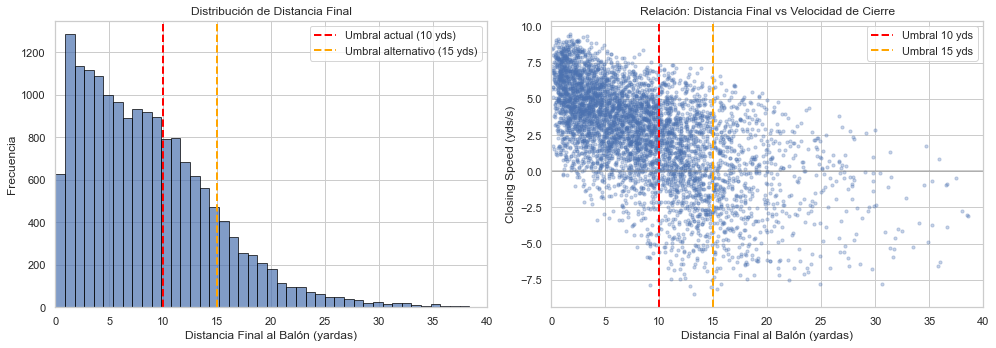

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# ANÁLISIS DEL UMBRAL DE DISTANCIA FINAL
# =============================================================================

print("=" * 60)
print("ANÁLISIS DEL UMBRAL DE DISTANCIA FINAL")
print("=" * 60)

# Usamos df_full_season filtrado solo por tiempo
df_base = df_full_season[df_full_season['tiempo_seg'] >= 1.0].copy()

print(f"\nTotal jugadas con tiempo >= 1.0s: {len(df_base)}")

# 1. Distribución de dist_final
print("\n1. DISTRIBUCIÓN DE DISTANCIA FINAL:")
print("-" * 40)
for umbral in [5, 7, 10, 12, 15, 20, 25]:
    n = (df_base['dist_final'] < umbral).sum()
    pct = n / len(df_base) * 100
    print(f"   dist_final < {umbral:2d} yds: {n:5d} jugadas ({pct:5.1f}%)")

# 2. Percentiles de dist_final
print("\n2. PERCENTILES DE DISTANCIA FINAL:")
print("-" * 40)
for p in [25, 50, 75, 90, 95, 99]:
    val = np.percentile(df_base['dist_final'], p)
    print(f"   P{p}: {val:.2f} yardas")

# 3. Jugadas entre 10-15 yardas
df_10_15 = df_base[(df_base['dist_final'] >= 10) & (df_base['dist_final'] < 15)]
df_under_10 = df_base[df_base['dist_final'] < 10]

print("\n3. COMPARACIÓN DE GRUPOS:")
print("-" * 40)
print(f"   Jugadas < 10 yds: {len(df_under_10)}")
print(f"   Jugadas 10-15 yds: {len(df_10_15)}")

print("\n   Closing speed promedio:")
print(f"   < 10 yds: {df_under_10['closing_speed'].mean():.2f} yds/s")
print(f"   10-15 yds: {df_10_15['closing_speed'].mean():.2f} yds/s")

print("\n   Yardas recuperadas promedio:")
print(f"   < 10 yds: {df_under_10['yardas_recuperadas'].mean():.2f} yds")
print(f"   10-15 yds: {df_10_15['yardas_recuperadas'].mean():.2f} yds")

# 4. Relevancia en jugadas 10-15 yds
print("\n4. ANÁLISIS DE RELEVANCIA:")
print("-" * 40)

relevantes_10_15 = df_10_15[df_10_15['yardas_recuperadas'] > 0]
print(f"   Jugadas 10-15 yds con recuperación positiva: {len(relevantes_10_15)}")
print(f"   % del grupo 10-15: {len(relevantes_10_15) / len(df_10_15) * 100:.1f}%")

# 5. Contexto táctico
print("\n5. CONTEXTO TÁCTICO:")
print("-" * 40)
print("   - < 5 yds: Cobertura muy cerrada (man-to-man tight)")
print("   - 5-10 yds: Zona de contestación del pase")
print("   - 10-15 yds: En camino pero probablemente tarde")
print("   - > 15 yds: Fuera de la jugada (otra zona)")

# 6. Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de dist_final
axes[0].hist(df_base['dist_final'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(10, color='red', linestyle='--', linewidth=2, label='Umbral actual (10 yds)')
axes[0].axvline(15, color='orange', linestyle='--', linewidth=2, label='Umbral alternativo (15 yds)')
axes[0].set_xlabel('Distancia Final al Balón (yardas)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Distancia Final')
axes[0].legend()
axes[0].set_xlim(0, 40)

# Scatter: dist_final vs closing_speed
sample = df_base.sample(n=min(5000, len(df_base)), random_state=42)
axes[1].scatter(sample['dist_final'], sample['closing_speed'], alpha=0.3, s=10)
axes[1].axvline(10, color='red', linestyle='--', linewidth=2, label='Umbral 10 yds')
axes[1].axvline(15, color='orange', linestyle='--', linewidth=2, label='Umbral 15 yds')
axes[1].axhline(0, color='gray', linestyle='-', alpha=0.5)
axes[1].set_xlabel('Distancia Final al Balón (yardas)')
axes[1].set_ylabel('Closing Speed (yds/s)')
axes[1].set_title('Relación: Distancia Final vs Velocidad de Cierre')
axes[1].legend()
axes[1].set_xlim(0, 40)

plt.tight_layout()
plt.savefig('analisis_umbral_distancia.png', dpi=150, bbox_inches='tight')
plt.show()



"We filter to defenders within 10 yards of the ball's landing spot at the moment of arrival. This threshold captures players who were actively contesting the catch while excluding those who were covering other zones or reacting too late to influence the play. Analysis showed that defenders beyond 10 yards averaged only 0.49 yds/s closing speed compared to 3.63 yds/s for those within range."

# ANÁLISIS DEL UMBRAL DE TIEMPO MÍNIMO

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# ANÁLISIS DEL UMBRAL DE TIEMPO MÍNIMO
# =============================================================================

print("=" * 60)
print("ANÁLISIS DEL UMBRAL DE TIEMPO MÍNIMO")
print("=" * 60)

# Usamos df_full_season sin filtro de tiempo
df_base = df_full_season.copy()

print(f"\nTotal trayectorias: {len(df_base)}")

# 1. Distribución de tiempo_seg
print("\n1. DISTRIBUCIÓN DE TIEMPO DE VUELO:")
print("-" * 40)
for umbral in [0.5, 0.7, 1.0, 1.2, 1.5, 2.0, 2.5]:
    n = (df_base['tiempo_seg'] >= umbral).sum()
    pct = n / len(df_base) * 100
    print(f"   tiempo >= {umbral:.1f}s: {n:5d} jugadas ({pct:5.1f}%)")

# 2. Percentiles de tiempo
print("\n2. PERCENTILES DE TIEMPO DE VUELO:")
print("-" * 40)
for p in [5, 10, 25, 50, 75, 90, 95]:
    val = np.percentile(df_base['tiempo_seg'], p)
    print(f"   P{p}: {val:.2f} segundos")

# 3. Comparación de grupos por tiempo
df_short = df_base[(df_base['tiempo_seg'] >= 0.5) & (df_base['tiempo_seg'] < 1.0)]
df_medium = df_base[(df_base['tiempo_seg'] >= 1.0) & (df_base['tiempo_seg'] < 1.5)]
df_long = df_base[df_base['tiempo_seg'] >= 1.5]

print("\n3. COMPARACIÓN DE GRUPOS:")
print("-" * 40)
print(f"   Jugadas 0.5-1.0s: {len(df_short)}")
print(f"   Jugadas 1.0-1.5s: {len(df_medium)}")
print(f"   Jugadas >= 1.5s: {len(df_long)}")

# 4. Estadísticas de closing_speed por grupo
print("\n4. CLOSING SPEED POR GRUPO DE TIEMPO:")
print("-" * 40)

for nombre, grupo in [("0.5-1.0s", df_short), ("1.0-1.5s", df_medium), (">=1.5s", df_long)]:
    if len(grupo) > 0:
        print(f"\n   Grupo {nombre} ({len(grupo)} jugadas):")
        print(f"      Mean: {grupo['closing_speed'].mean():.2f} yds/s")
        print(f"      Std:  {grupo['closing_speed'].std():.2f} yds/s")
        print(f"      Min:  {grupo['closing_speed'].min():.2f} yds/s")
        print(f"      Max:  {grupo['closing_speed'].max():.2f} yds/s")

# 5. Estabilidad matemática: división por tiempos pequeños
print("\n5. ANÁLISIS DE ESTABILIDAD MATEMÁTICA:")
print("-" * 40)

for t_min in [0.5, 0.7, 1.0]:
    grupo = df_base[df_base['tiempo_seg'] >= t_min]
    cv = grupo['closing_speed'].std() / grupo['closing_speed'].mean()
    print(f"   Tiempo >= {t_min:.1f}s: CV = {cv:.3f} (menor es más estable)")

# 6. Valores extremos en tiempos cortos
print("\n6. VALORES EXTREMOS POR GRUPO:")
print("-" * 40)

df_very_short = df_base[df_base['tiempo_seg'] < 1.0]
if len(df_very_short) > 0:
    extremos_high = (df_very_short['closing_speed'] > 10).sum()
    extremos_low = (df_very_short['closing_speed'] < -8).sum()
    total_ext = extremos_high + extremos_low
    pct_ext = total_ext / len(df_very_short) * 100
    print(f"   Jugadas < 1.0s con speed > 10: {extremos_high}")
    print(f"   Jugadas < 1.0s con speed < -8: {extremos_low}")
    print(f"   Total extremos: {total_ext} ({pct_ext:.1f}%)")

# 7. Contexto táctico
print("\n7. CONTEXTO TÁCTICO (Tiempo de vuelo del balón):")
print("-" * 40)
print("   - < 0.5s: Pases de pantalla, muy cortos (casi handoff)")
print("   - 0.5-1.0s: Pases rápidos (slants, quick outs)")
print("   - 1.0-1.5s: Pases intermedios (curls, digs)")
print("   - 1.5-2.5s: Pases profundos (posts, gos)")
print("   - > 2.5s: Pases muy profundos o jugadas extendidas")
'''
# 8. Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de tiempo
axes[0].hist(df_base['tiempo_seg'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(0.5, color='green', linestyle='--', linewidth=2, label='0.5s')
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=2, label='1.0s (actual)')
axes[0].axvline(1.5, color='orange', linestyle='--', linewidth=2, label='1.5s')
axes[0].set_xlabel('Tiempo de Vuelo (segundos)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Tiempo de Vuelo del Balón')
axes[0].legend()
axes[0].set_xlim(0, 4)

# Scatter: tiempo vs closing_speed
sample = df_base.sample(n=min(5000, len(df_base)), random_state=42)
axes[1].scatter(sample['tiempo_seg'], sample['closing_speed'], alpha=0.3, s=10)
axes[1].axvline(0.5, color='green', linestyle='--', linewidth=2)
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=2)
axes[1].axhline(0, color='gray', linestyle='-', alpha=0.5)
axes[1].set_xlabel('Tiempo de Vuelo (segundos)')
axes[1].set_ylabel('Closing Speed (yds/s)')
axes[1].set_title('Relación Tiempo vs Velocidad de Cierre')
axes[1].set_xlim(0, 4)
axes[1].set_ylim(-15, 15)

plt.tight_layout()
plt.savefig('analisis_umbral_tiempo.png', dpi=150, bbox_inches='tight')
plt.show()

# 9. Recomendación
print("\n8. ANÁLISIS PARA RECOMENDACIÓN:")
print("-" * 40)

for t in [0.5, 0.7, 0.8, 1.0, 1.2]:
    n_incluidos = (df_base['tiempo_seg'] >= t).sum()
    n_excluidos = len(df_base) - n_incluidos
    pct_excluidos = n_excluidos / len(df_base) * 100
    std = df_base[df_base['tiempo_seg'] >= t]['closing_speed'].std()
    print(f"   >= {t:.1f}s: Excluye {n_excluidos:5d} ({pct_excluidos:4.1f}%), Std = {std:.2f}")
'''

ANÁLISIS DEL UMBRAL DE TIEMPO MÍNIMO

Total trayectorias: 17154

1. DISTRIBUCIÓN DE TIEMPO DE VUELO:
----------------------------------------
   tiempo >= 0.5s: 17154 jugadas (100.0%)
   tiempo >= 0.7s: 17154 jugadas (100.0%)
   tiempo >= 1.0s: 17154 jugadas (100.0%)
   tiempo >= 1.2s: 14373 jugadas ( 83.8%)
   tiempo >= 1.5s:  8539 jugadas ( 49.8%)
   tiempo >= 2.0s:  3963 jugadas ( 23.1%)
   tiempo >= 2.5s:  1611 jugadas (  9.4%)

2. PERCENTILES DE TIEMPO DE VUELO:
----------------------------------------
   P5: 1.10 segundos
   P10: 1.10 segundos
   P25: 1.20 segundos
   P50: 1.40 segundos
   P75: 1.90 segundos
   P90: 2.40 segundos
   P95: 2.70 segundos

3. COMPARACIÓN DE GRUPOS:
----------------------------------------
   Jugadas 0.5-1.0s: 0
   Jugadas 1.0-1.5s: 8615
   Jugadas >= 1.5s: 8539

4. CLOSING SPEED POR GRUPO DE TIEMPO:
----------------------------------------

   Grupo 1.0-1.5s (8615 jugadas):
      Mean: 1.64 yds/s
      Std:  3.19 yds/s
      Min:  -8.56 yds/s
      M

'\n# 8. Visualización\nfig, axes = plt.subplots(1, 2, figsize=(14, 5))\n\n# Histograma de tiempo\naxes[0].hist(df_base[\'tiempo_seg\'], bins=30, edgecolor=\'black\', alpha=0.7)\naxes[0].axvline(0.5, color=\'green\', linestyle=\'--\', linewidth=2, label=\'0.5s\')\naxes[0].axvline(1.0, color=\'red\', linestyle=\'--\', linewidth=2, label=\'1.0s (actual)\')\naxes[0].axvline(1.5, color=\'orange\', linestyle=\'--\', linewidth=2, label=\'1.5s\')\naxes[0].set_xlabel(\'Tiempo de Vuelo (segundos)\')\naxes[0].set_ylabel(\'Frecuencia\')\naxes[0].set_title(\'Distribución de Tiempo de Vuelo del Balón\')\naxes[0].legend()\naxes[0].set_xlim(0, 4)\n\n# Scatter: tiempo vs closing_speed\nsample = df_base.sample(n=min(5000, len(df_base)), random_state=42)\naxes[1].scatter(sample[\'tiempo_seg\'], sample[\'closing_speed\'], alpha=0.3, s=10)\naxes[1].axvline(0.5, color=\'green\', linestyle=\'--\', linewidth=2)\naxes[1].axvline(1.0, color=\'red\', linestyle=\'--\', linewidth=2)\naxes[1].axhline(0, color=\'gra

We require a minimum ball flight time of 1. 0 seconds to ensure defenders have sufficient time to demonstrate closing ability. Shorter passes (screens, quick slants) do not provide enough tracking frames to reliably measure acceleration patterns. This threshold yields a logarithmic model with R² = 0. 56, indicating that initial distance explains over half the variance in closing speed - the remainder being the player's individual effort (CSOE).